# RamanBench — Benchmarking a New Model

This notebook shows how to evaluate a new model against the 28 precomputed baselines.

## Ecosystem

| Resource                       | Link                                                                                               |
|--------------------------------|----------------------------------------------------------------------------------------------------|
| **raman-data** (datasets)      | [GitHub](https://github.com/ml-lab-htw/raman_data) · [PyPI](https://pypi.org/project/raman-data/)  |
| **raman-bench** (this package) | [GitHub](https://github.com/ml-lab-htw/RamanBench) · [PyPI](https://pypi.org/project/raman-bench/) |
| **Live Leaderboard**           | [HuggingFace Space](https://huggingface.co/spaces/HTW-KI-Werkstatt/RamanBench)                           |
| **Paper**                      | [arXiv TBD](https://arxiv.org/abs/TBD)                                                             |

In [1]:
# !pip install raman-bench raman-data scikit-learn

## Option A: Scikit-learn compatible model (simplest)

In [2]:
from raman_bench import Leaderboard
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier

# Load precomputed baselines
lb = Leaderboard.from_precomputed()

print('Current #1 model:', lb.rank().iloc[0]['Model'])

Current #1 model: AutoGluon 1.5 (extreme, 4h)


In [3]:
results = lb.evaluate_and_add(
    model_name="PLS-2",
    model=PLSRegression(n_components=2),
    task="regression",
    seeds=3,
)
print(f"Evaluated on {len(results)} (dataset, seed) combinations")

2026-06-05 22:42:59,645 INFO raman_bench.benchmark:__init__:182: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 19959.30it/s]
2026-06-05 22:43:03,018 INFO raman_bench.benchmark:__init__:182: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 59837.22it/s]
2026-06-05 22:43:06,325 INFO raman_bench.benchmark:__init__:182: Datasets: 21 classification, 56 regression
Loading datasets: 100%|██████████| 21/21 [00:00<00:00, 23438.10it/s]
2026-06-05 22:43:10,017 INFO raman_bench.leaderboard:add_results:256: Added model 'PLS-2' to leaderboard.


Evaluated on 444 (dataset, seed) combinations


In [4]:
# View updated regression ranking
ranked = lb.rank(task="regression")
pls_row = ranked[ranked["Model"] == "PLS-2"]
pls_rank = pls_row.index[0] + 1
print(f"PLS-2 ranked #{pls_rank} out of {len(ranked)} models (regression)")
ranked.head(20)


PLS-2 ranked #19 out of 28 models (regression)


,Rank,model_id,Model,Category,Elo,Score,Avg Rank,Improvability,Train Time s,Infer. s/1K
0,1,AUTOGLUON,"AutoGluon 1.5 (extreme, 4h)",AutoML,1558.0,0.7973,3.8,20.3,1776.300000,220.700000
1,2,REALTABPFN-V2.5,TabPFN v2.5,Tabular Foundation,1529.0,0.7654,4.0,23.5,89.600000,100.800000
2,3,REALTABPFN-V2,TabPFN v2,Tabular Foundation,1402.0,0.6744,5.8,32.6,77.600000,146.400000
3,4,TABICL,TabICL,Tabular Foundation,1443.0,0.6398,5.5,36.0,39.900000,130.300000
4,5,MITRA,MITRA,Tabular Foundation,1312.0,0.5147,7.4,48.5,827.400000,626.500000
5,6,TABDPT,TabDPT,Tabular Foundation,1136.0,0.2954,11.9,70.5,12.300000,80.200000
6,7,REZERONET,ReZeroNet,Raman-Specific,1133.0,0.2630,12.8,73.7,44.600000,23.100000
7,8,PLS,PLS,Traditional ML,1004.0,0.2256,15.1,77.4,29.700000,19.200000
8,9,REALMLP,RealMLP,Deep Learning,1111.0,0.2252,13.0,77.5,1935.500000,71.100000
9,10,LR,Logistic Reg.,Traditional ML,1002.0,0.2153,15.6,78.5,37.200000,41.200000


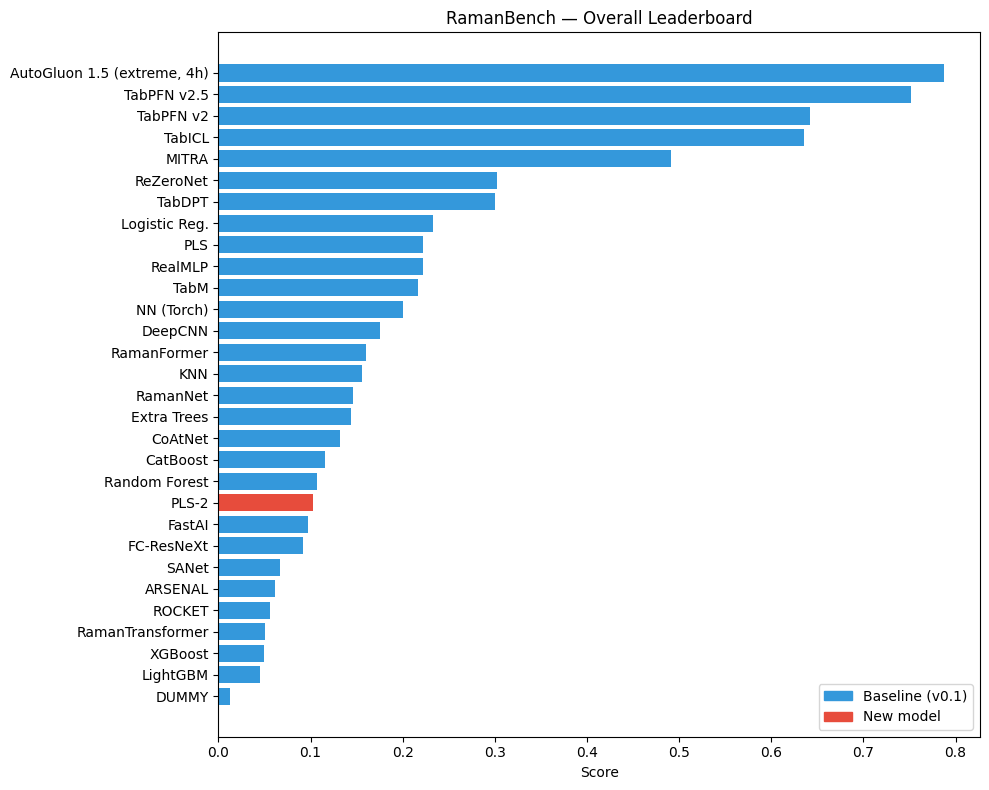

In [5]:
import matplotlib.pyplot as plt

fig = lb.plot(task='overall', n_top=35)
plt.show()

## Option B: Adding results from a pre-existing run

If you have already run your model and computed metrics, you can add the results directly:

In [6]:
import pandas as pd
from raman_bench import Leaderboard

# Your pre-computed metrics DataFrame
# Must have columns: seed, key, and metric columns (rmse/r2 for regression, f1_score for classification)
my_metrics = pd.DataFrame({
    'seed': [0, 1, 2],
    'key': ['amino_acids_glycine_0', 'amino_acids_glycine_0', 'amino_acids_glycine_0'],
    'rmse': [0.84, 0.85, 0.83],
    'r2': [0.82, 0.81, 0.83],
})

lb = Leaderboard.from_precomputed()
lb.add_results('My Existing Model', my_metrics)

# Note: models with partial coverage are penalised on missing datasets
# (norm_score=0, rank=last+1), so overall rank reflects full-benchmark performance.
# To get a meaningful leaderboard position, submit results for all dataset keys.
print(lb.rank().tail(5))

2026-06-05 22:43:10,215 INFO raman_bench.leaderboard:from_precomputed:136: Loaded precomputed leaderboard: 10449 regression rows, 1827 classification rows
2026-06-05 22:43:10,292 INFO raman_bench.leaderboard:add_results:256: Added model 'My Existing Model' to leaderboard.


    Rank           model_id              Model           Category    Elo  \
25    26   RAMANTRANSFORMER   RamanTransformer     Raman-Specific  710.0   
26    27                XGB            XGBoost  Gradient Boosting  923.0   
27    28                GBM           LightGBM  Gradient Boosting  950.0   
28    29              DUMMY              DUMMY                NaN    NaN   
29    30  My Existing Model  My Existing Model                NaN    NaN   

     Score  Avg Rank  Improvability  Train Time s  Infer. s/1K  
25  0.0494      22.6           95.1         429.8        134.8  
26  0.0471      18.0           95.3          57.9          3.7  
27  0.0432      17.0           95.7        1453.5          7.3  
28  0.0121      23.2           98.8           NaN          NaN  
29  0.0035      28.1           99.7           NaN          NaN  


## Option C: Full benchmark run via AutoGluon

For AutoGluon-integrated models, use the CLI:

```bash
# Run a specific model
raman-bench run --config configs/benchmark_v0.1.json --model MYMODEL

# Then load results and compare
```

See [CONTRIBUTING.md](../CONTRIBUTING.md) for instructions on implementing a fully
integrated AutoGluon model.